# Importing necessary libraries

In [4]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Importing the GeoTiff file

In [5]:
file = "/content/drive/MyDrive/Agri_RS_AI_Project/03_Phase_1_5_Validation_Layer_&_Time_Series_Entry/python_validation/1_Satelite_Data_as_Numbers/data/Sentinel2_Sylhet.tif"

In [6]:
with rasterio.open(file) as src:
   print("Shape:", src.read().shape)

   red = src.read(3).astype(float)
   nir = src.read(4).astype(float)

Shape: (4, 1002, 1098)


# Applying Scaling and Compuote NVDI


In [7]:
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.scal_ndvi import ndvi

ndvi = ndvi(red,nir)

## From GEE

In [8]:
# Import File
ndvi_gee_tif = "/content/drive/MyDrive/Agri_RS_AI_Project/03_Phase_1_5_Validation_Layer_&_Time_Series_Entry/python_validation/1_Satelite_Data_as_Numbers/data/NDVI_export.tif"

In [9]:
with rasterio.open(ndvi_gee_tif) as src:
   print("Shape:", src.read().shape)

   ndvi_gee = src.read(1).astype(float)

Shape: (1, 1002, 1098)


# Compare with GEE NDVI

In [10]:
#This should be form -1 to 1
print(ndvi.min(), ndvi.max())

-0.4395393474088291 0.8754709498314496


In [11]:
print(ndvi_gee.min(), ndvi_gee.max())

-0.4395393431186676 0.8754709362983704


# Histogram Plotting

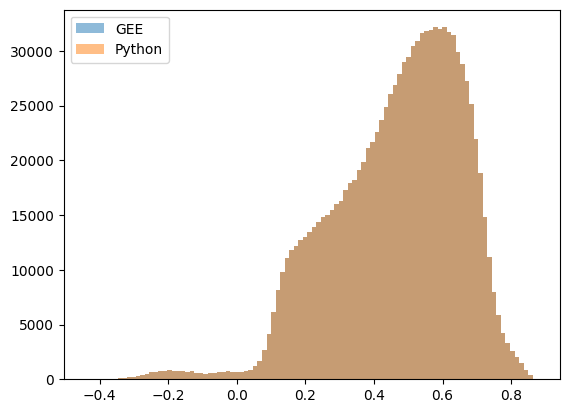

In [12]:
# both in same plot --> if difference present the other color also shown here.
plt.hist(ndvi_gee.flatten(), bins=100, alpha=0.5, label="GEE")
plt.hist(ndvi.flatten(), bins=100, alpha=0.5, label="Python")
plt.legend()
plt.show()


# Spatial pattern check

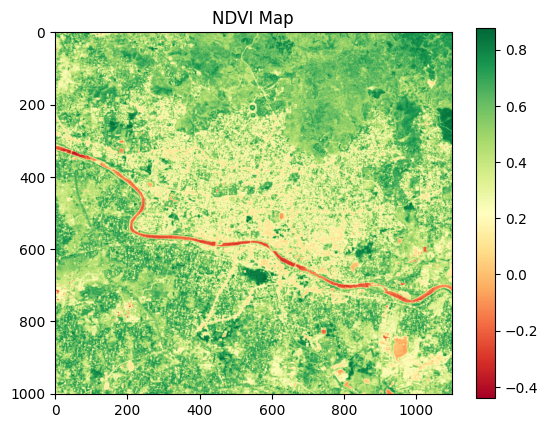

In [13]:
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.visual_ndvi import vis_ndvi

vis_ndvi(ndvi)

## From GEE to Map

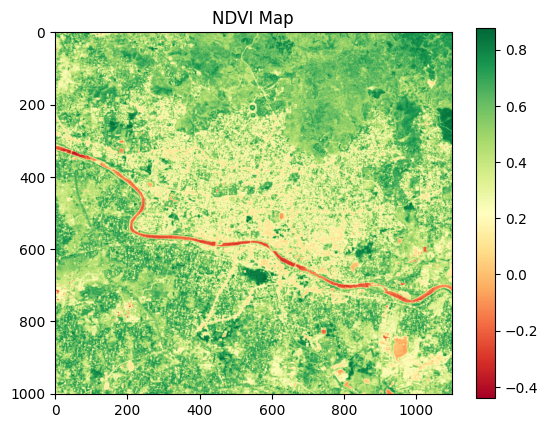

In [15]:
vis_ndvi(ndvi_gee)